
# CelebA-Spoof vs SCRFD Bounding-Box Shift Analysis

Mục tiêu duy nhất của notebook này:

> **Định lượng mức sai lệch giữa bbox annotation của CelebA-Spoof và bbox do SCRFD phát hiện trên chính cùng một ảnh.**

So sánh:

```text
Train:
CelebA annotation bbox
→ expand 1.5×
→ PAD model

Detector path:
SCRFD bbox
→ expand 1.5×
→ PAD model
```

Notebook đo:
- SCRFD detection failure rate;
- raw bbox IoU;
- center shift chuẩn hóa theo kích thước mặt;
- width/height/area/scale ratio;
- IoU sau khi cả hai bbox cùng expand `1.5×`;
- gallery các case lệch mạnh nhất;
- histogram và percentile;
- tỷ lệ sample có shift nhỏ / vừa / lớn.

> Đây là diagnostic notebook, không phải benchmark PAD.


In [1]:

!pip install -q insightface onnxruntime pandas scikit-learn

import os, json, math, random
from pathlib import Path

import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from tqdm.auto import tqdm

from insightface.app import FaceAnalysis

SEED = 42
random.seed(SEED)
np.random.seed(SEED)

print("OpenCV:", cv2.__version__)


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.1/1.1 MB 16.4 MB/s eta 0:00:00a 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 23.6/23.6 MB 73.9 MB/s eta 0:00:00:00:0100:01
OpenCV: 4.13.0



## Configuration

Mặc định dùng `test_label.json`.

- `SAMPLE_SIZE = 5000`: đủ để ước lượng distribution khá ổn và chạy nhanh hơn.
- `SAMPLE_SIZE = None`: chạy toàn bộ split.


In [2]:

DATA_ROOT = Path(
    "/kaggle/input/datasets/attentionlayer241/celeba-spoof-for-face-antispoofing/"
    "CelebA_Spoof_/CelebA_Spoof"
)

SPLIT = "test"
SAMPLE_SIZE = 5000
SCRFD_DET_SIZE = (640, 640)
SCRFD_CONF_THRESH = 0.5
EXPANSION_FACTOR = 1.5
SAVE_RESULTS = True
SHOW_WORST_N = 24

JSON_PATH = DATA_ROOT / f"metas/intra_test/{SPLIT}_label.json"
assert DATA_ROOT.exists(), DATA_ROOT
assert JSON_PATH.exists(), JSON_PATH

with open(JSON_PATH, "r") as f:
    meta = json.load(f)

all_keys = list(meta.keys())
rng = np.random.default_rng(SEED)

if SAMPLE_SIZE is None or SAMPLE_SIZE >= len(all_keys):
    keys = all_keys
else:
    keys = rng.choice(all_keys, size=SAMPLE_SIZE, replace=False).tolist()

print("Split:", SPLIT)
print("Total split size:", len(all_keys))
print("Selected:", len(keys))
print("Expansion factor:", EXPANSION_FACTOR)


Split: test
Total split size: 67170
Selected: 5000
Expansion factor: 1.5


In [3]:

app = FaceAnalysis(
    name="buffalo_s",
    allowed_modules=["detection"],
    providers=["CPUExecutionProvider"],
)
app.prepare(
    ctx_id=-1,
    det_size=SCRFD_DET_SIZE,
    det_thresh=SCRFD_CONF_THRESH,
)

scrfd = app.models.get("detection")
if scrfd is None:
    raise RuntimeError("SCRFD detection model not found in buffalo_s")

print("SCRFD ready")
print("det_size:", SCRFD_DET_SIZE)
print("conf_thresh:", SCRFD_CONF_THRESH)


download_path: /root/.insightface/models/buffalo_s


100%|██████████| 124617/124617 [00:01<00:00, 88443.55KB/s] 


SCRFD ready
det_size: (640, 640)
conf_thresh: 0.5


In [4]:

def read_celeba_bbox(img_path):
    bb_path = Path(str(img_path.with_suffix("")) + "_BB.txt")
    if not bb_path.exists():
        raise FileNotFoundError(bb_path)

    with open(bb_path, "r") as f:
        parts = f.readline().strip().split()

    if len(parts) < 4:
        raise ValueError(f"Invalid bbox file: {bb_path}")

    x, y, w, h = map(float, parts[:4])

    image = cv2.imread(str(img_path), cv2.IMREAD_COLOR)
    if image is None:
        raise FileNotFoundError(img_path)

    H, W = image.shape[:2]

    x = x / 224.0 * W
    y = y / 224.0 * H
    w = w / 224.0 * W
    h = h / 224.0 * H

    if w <= 0 or h <= 0:
        raise ValueError(f"Non-positive bbox: {(x,y,w,h)}")

    return np.array([x, y, x+w, y+h], dtype=np.float64), image


def bbox_area(b):
    x1,y1,x2,y2 = map(float,b)
    return max(0.0,x2-x1) * max(0.0,y2-y1)


def bbox_iou(a,b):
    ax1,ay1,ax2,ay2 = map(float,a)
    bx1,by1,bx2,by2 = map(float,b)
    ix1=max(ax1,bx1); iy1=max(ay1,by1)
    ix2=min(ax2,bx2); iy2=min(ay2,by2)
    iw=max(0.0,ix2-ix1); ih=max(0.0,iy2-iy1)
    inter=iw*ih
    union=bbox_area(a)+bbox_area(b)-inter
    return 0.0 if union <= 0 else inter/union


def bbox_center(b):
    x1,y1,x2,y2 = map(float,b)
    return np.array([(x1+x2)/2.0,(y1+y2)/2.0])


def bbox_wh(b):
    x1,y1,x2,y2 = map(float,b)
    return np.array([x2-x1,y2-y1],dtype=np.float64)


def expand_square_bbox(b, factor=1.5):
    x1,y1,x2,y2 = map(float,b)
    w=x2-x1; h=y2-y1
    side=max(w,h)*float(factor)
    cx=(x1+x2)/2.0
    cy=(y1+y2)/2.0
    return np.array([cx-side/2.0,cy-side/2.0,cx+side/2.0,cy+side/2.0],dtype=np.float64)


def clip_bbox(b, W, H):
    x1,y1,x2,y2 = map(float,b)
    return np.array([
        np.clip(x1,0,W), np.clip(y1,0,H),
        np.clip(x2,0,W), np.clip(y2,0,H)
    ],dtype=np.float64)


def normalized_center_shift(gt, det):
    gt_wh = bbox_wh(gt)
    denom = max(gt_wh[0], gt_wh[1], 1e-6)
    return float(np.linalg.norm(bbox_center(gt)-bbox_center(det))/denom)


def select_scrfd_match(bboxes, gt_bbox):
    if bboxes is None or len(bboxes) == 0:
        return None, None, 0
    ious = [bbox_iou(row[:4], gt_bbox) for row in bboxes]
    idx = int(np.argmax(ious))
    return np.asarray(bboxes[idx][:4], dtype=np.float64), float(bboxes[idx][4]), len(bboxes)


In [5]:

rows = []
errors = []

for key in tqdm(keys, desc="SCRFD vs CelebA bbox"):
    img_path = DATA_ROOT / key

    try:
        gt, image = read_celeba_bbox(img_path)
        H, W = image.shape[:2]

        bboxes, kps = scrfd.detect(image, max_num=0, metric="default")
        det, conf, n_faces = select_scrfd_match(bboxes, gt)

        base = {
            "key": key,
            "image_w": W,
            "image_h": H,
            "n_scrfd_faces": int(n_faces),
            "detected": det is not None,
        }

        if det is None:
            rows.append(base)
            continue

        gt_w, gt_h = bbox_wh(gt)
        dt_w, dt_h = bbox_wh(det)

        gt_exp = expand_square_bbox(gt, EXPANSION_FACTOR)
        dt_exp = expand_square_bbox(det, EXPANSION_FACTOR)

        gt_exp_clip = clip_bbox(gt_exp, W, H)
        dt_exp_clip = clip_bbox(dt_exp, W, H)

        row = {
            **base,
            "scrfd_conf": conf,
            "gt_x1":gt[0], "gt_y1":gt[1], "gt_x2":gt[2], "gt_y2":gt[3],
            "det_x1":det[0], "det_y1":det[1], "det_x2":det[2], "det_y2":det[3],
            "raw_iou": bbox_iou(gt, det),
            "center_shift_norm": normalized_center_shift(gt, det),
            "width_ratio_det_over_gt": dt_w / max(gt_w, 1e-8),
            "height_ratio_det_over_gt": dt_h / max(gt_h, 1e-8),
            "area_ratio_det_over_gt": bbox_area(det) / max(bbox_area(gt), 1e-8),
            "scale_ratio_det_over_gt": max(dt_w,dt_h) / max(max(gt_w,gt_h),1e-8),
            "expanded_iou": bbox_iou(gt_exp, dt_exp),
            "expanded_iou_clipped": bbox_iou(gt_exp_clip, dt_exp_clip),
            "expanded_area_ratio_det_over_gt": bbox_area(dt_exp) / max(bbox_area(gt_exp),1e-8),
        }
        rows.append(row)

    except Exception as exc:
        errors.append((key, repr(exc)))

df = pd.DataFrame(rows)

print("Rows:", len(df))
print("Errors:", len(errors))
if errors[:5]:
    print("First errors:")
    for e in errors[:5]:
        print(" ", e)

display(df.head())


SCRFD vs CelebA bbox:   0%|          | 0/5000 [00:00<?, ?it/s]

Rows: 5000
Errors: 0


,key,image_w,image_h,n_scrfd_faces,detected,scrfd_conf,gt_x1,gt_y1,gt_x2,gt_y2,...,det_y2,raw_iou,center_shift_norm,width_ratio_det_over_gt,height_ratio_det_over_gt,area_ratio_det_over_gt,scale_ratio_det_over_gt,expanded_iou,expanded_iou_clipped,expanded_area_ratio_det_over_gt
0,Data/test/8873/live/525403.png,283,390,1,True,0.781969,69.486607,99.241071,210.986607,315.133929,...,321.370331,0.900329,0.006799,1.050833,1.056976,1.110706,1.056976,0.895096,0.946095,1.117199
1,Data/test/7886/live/536590.png,360,382,1,True,0.856897,112.500000,83.562500,265.178571,295.026786,...,296.018188,0.959200,0.007112,1.018656,1.023442,1.042536,1.023442,0.954714,0.954714,1.047434
2,Data/test/5010/spoof/545352.png,480,640,1,True,0.848392,117.857143,145.714286,278.571429,394.285714,...,401.608765,0.898711,0.027470,1.069887,1.018627,1.089816,1.018627,0.950153,0.950153,1.037601
3,Data/test/8101/spoof/540830.png,450,600,1,True,0.702311,86.383929,241.071429,307.366071,573.214286,...,570.218567,0.860171,0.028830,1.131435,1.010270,1.143054,1.010270,0.949478,0.971284,1.020644
4,Data/test/7334/live/507570.png,300,300,1,True,0.825161,124.553571,68.303571,218.303571,184.821429,...,190.620697,0.895522,0.036212,1.000993,1.043388,1.044424,1.043388,0.918562,0.918562,1.088658


In [6]:

n_total = len(df)
n_detected = int(df["detected"].sum())
n_failed = n_total - n_detected
failure_rate = n_failed / max(n_total,1)

print(f"Total samples       : {n_total}")
print(f"SCRFD detected      : {n_detected}")
print(f"SCRFD no detection  : {n_failed}")
print(f"Detection failure   : {failure_rate*100:.3f}%")

d = df[df["detected"]].copy()

metrics = [
    "raw_iou",
    "expanded_iou",
    "expanded_iou_clipped",
    "center_shift_norm",
    "scale_ratio_det_over_gt",
    "area_ratio_det_over_gt",
    "width_ratio_det_over_gt",
    "height_ratio_det_over_gt",
]

summary = d[metrics].describe(
    percentiles=[0.01,0.05,0.10,0.25,0.5,0.75,0.90,0.95,0.99]
).T

display(summary)


Total samples       : 5000
SCRFD detected      : 4695
SCRFD no detection  : 305
Detection failure   : 6.100%


,count,mean,std,min,1%,5%,10%,25%,50%,75%,90%,95%,99%,max
raw_iou,4695.0,0.870484,0.064201,0.000000,0.678043,0.777433,0.807475,0.845165,0.878421,0.907770,0.932254,0.943767,0.963659,0.989551
expanded_iou,4695.0,0.889106,0.080288,0.000000,0.637855,0.756476,0.799216,0.855554,0.907803,0.942189,0.961672,0.970227,0.984015,0.999511
expanded_iou_clipped,4695.0,0.906349,0.078919,0.000000,0.648500,0.768513,0.815723,0.875794,0.926201,0.957699,0.976394,0.984806,0.995996,1.000000
center_shift_norm,4695.0,0.031666,0.111489,0.000238,0.002951,0.006589,0.009694,0.015991,0.024995,0.035807,0.047965,0.056254,0.089244,4.704205
scale_ratio_det_over_gt,4695.0,0.969264,0.070874,0.234416,0.810392,0.874194,0.900303,0.932657,0.966758,1.003241,1.041240,1.072478,1.131153,2.025490
area_ratio_det_over_gt,4695.0,1.021003,0.133955,0.151447,0.801398,0.885882,0.921519,0.967319,1.015491,1.061897,1.116279,1.156695,1.285913,4.095837
width_ratio_det_over_gt,4695.0,1.045419,0.081660,0.630548,0.833431,0.925829,0.964197,1.011386,1.048495,1.083254,1.116653,1.140877,1.213731,2.381960
height_ratio_det_over_gt,4695.0,0.976641,0.079077,0.234416,0.817037,0.875985,0.901455,0.933577,0.969028,1.010238,1.065766,1.103054,1.183363,2.171602


In [7]:

def shift_category(row):
    # Debug heuristics only; not literature-standard thresholds.
    eiou = row["expanded_iou"]
    center = row["center_shift_norm"]
    scale = row["scale_ratio_det_over_gt"]

    if eiou >= 0.85 and center <= 0.05 and 0.90 <= scale <= 1.10:
        return "small"
    if eiou >= 0.70 and center <= 0.12 and 0.75 <= scale <= 1.25:
        return "moderate"
    return "large"

d["shift_category"] = d.apply(shift_category, axis=1)

counts = d["shift_category"].value_counts().reindex(["small","moderate","large"], fill_value=0)

print("Diagnostic shift categories (heuristic):")
for k,v in counts.items():
    print(f"{k:>8}: {v:6d}  ({100*v/len(d):6.2f}%)")

print("\nDirect threshold rates:")
for th in [0.9,0.8,0.7,0.6,0.5]:
    print(f"expanded IoU < {th:.1f}: {100*(d['expanded_iou'] < th).mean():6.2f}%")

for th in [0.05,0.10,0.15,0.20]:
    print(f"center shift > {th:.2f} face-size: {100*(d['center_shift_norm'] > th).mean():6.2f}%")

for lo,hi in [(0.9,1.1),(0.8,1.2),(0.7,1.3)]:
    frac = ((d["scale_ratio_det_over_gt"] < lo) | (d["scale_ratio_det_over_gt"] > hi)).mean()
    print(f"scale outside [{lo:.1f},{hi:.1f}]: {100*frac:6.2f}%")


Diagnostic shift categories (heuristic):
   small:   3411  ( 72.65%)
moderate:   1165  ( 24.81%)
   large:    119  (  2.53%)

Direct threshold rates:
expanded IoU < 0.9:  44.92%
expanded IoU < 0.8:  10.10%
expanded IoU < 0.7:   2.47%
expanded IoU < 0.6:   0.75%
expanded IoU < 0.5:   0.34%
center shift > 0.05 face-size:   8.46%
center shift > 0.10 face-size:   0.55%
center shift > 0.15 face-size:   0.34%
center shift > 0.20 face-size:   0.23%
scale outside [0.9,1.1]:  12.16%
scale outside [0.8,1.2]:   1.15%
scale outside [0.7,1.3]:   0.40%


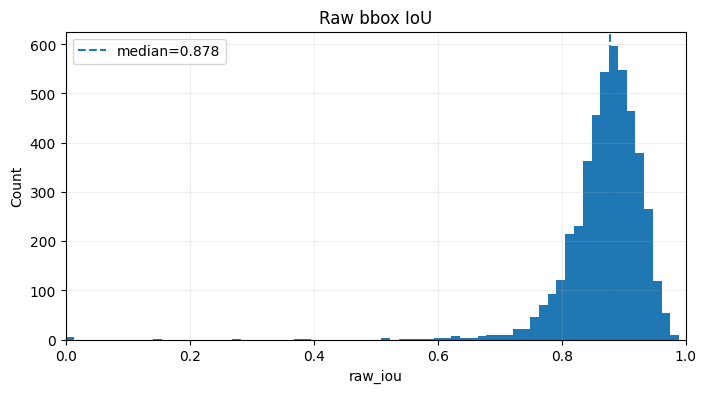

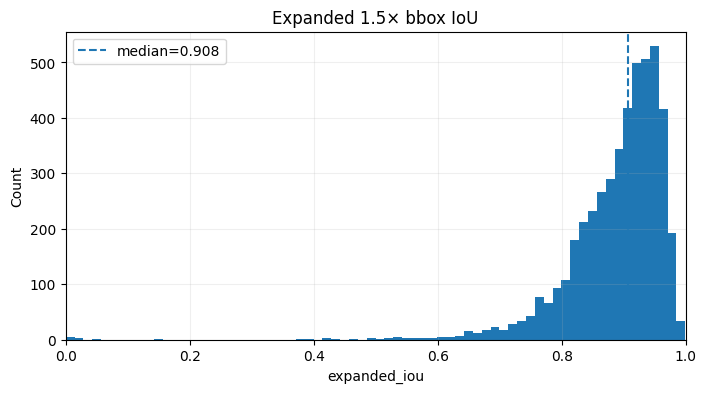

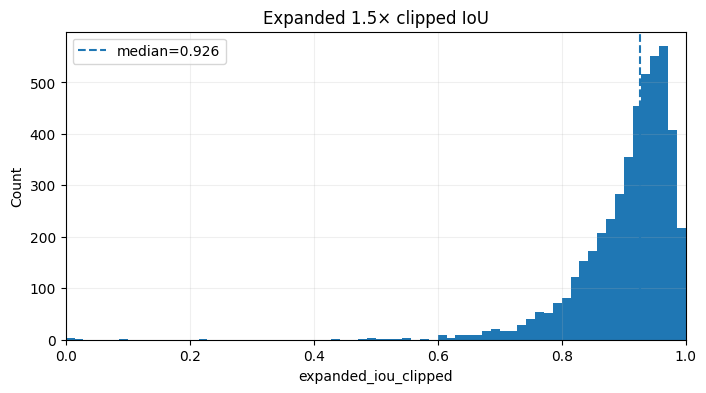

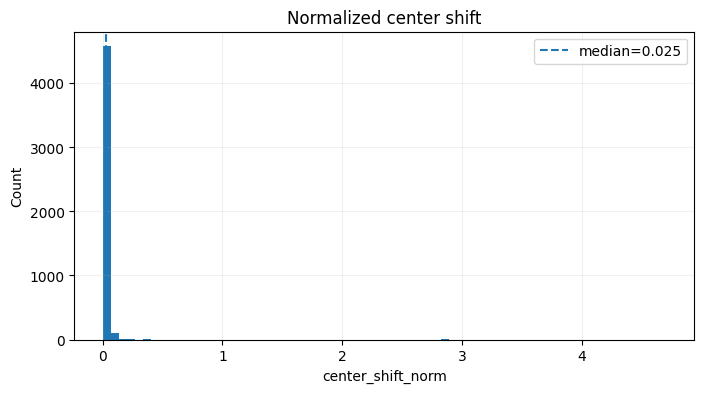

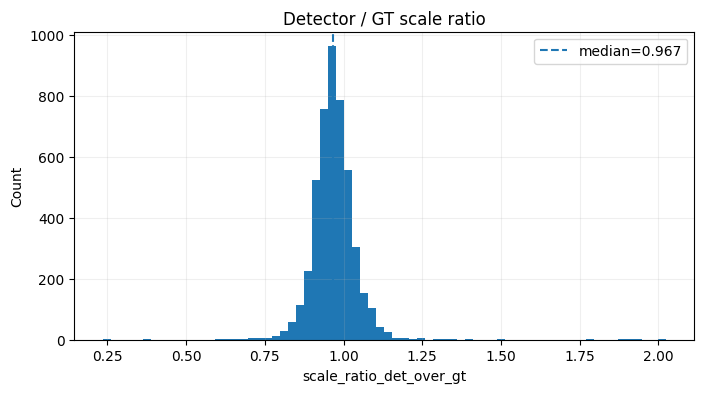

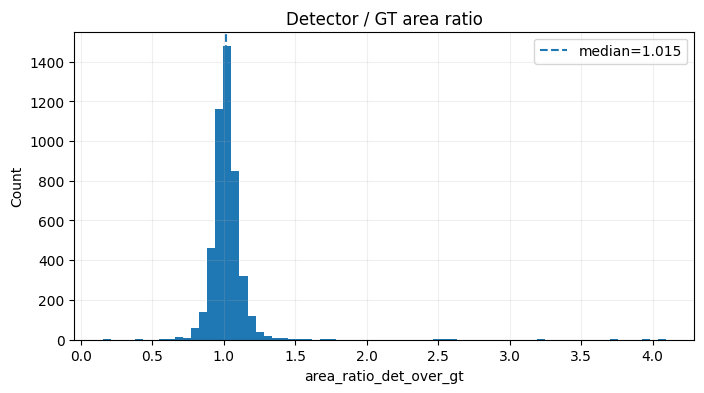

In [8]:

plots = [
    ("raw_iou", "Raw bbox IoU", (0,1)),
    ("expanded_iou", f"Expanded {EXPANSION_FACTOR}× bbox IoU", (0,1)),
    ("expanded_iou_clipped", f"Expanded {EXPANSION_FACTOR}× clipped IoU", (0,1)),
    ("center_shift_norm", "Normalized center shift", None),
    ("scale_ratio_det_over_gt", "Detector / GT scale ratio", None),
    ("area_ratio_det_over_gt", "Detector / GT area ratio", None),
]

for col,title,xlim in plots:
    plt.figure(figsize=(8,4))
    plt.hist(d[col].dropna(), bins=70)
    plt.axvline(d[col].median(), linestyle="--", label=f"median={d[col].median():.3f}")
    plt.xlabel(col)
    plt.ylabel("Count")
    plt.title(title)
    if xlim:
        plt.xlim(*xlim)
    plt.grid(alpha=0.2)
    plt.legend()
    plt.show()


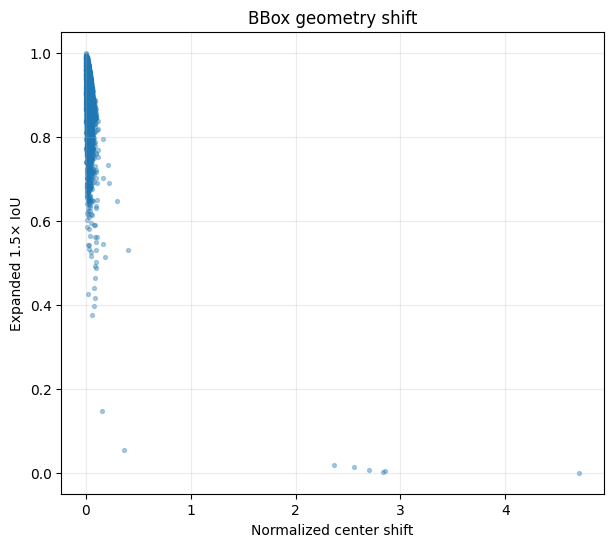

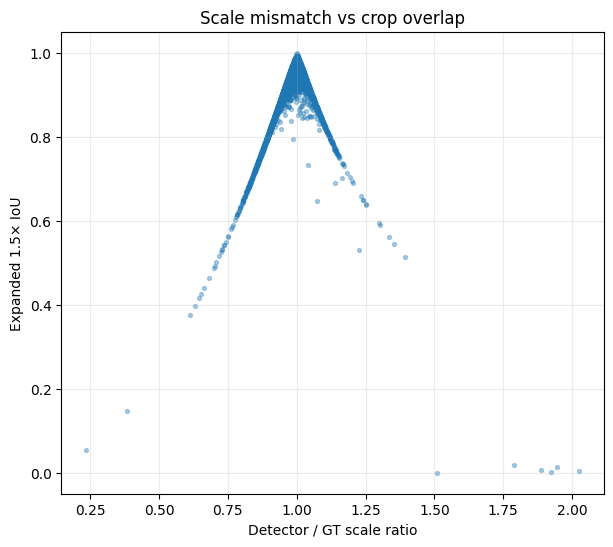

In [9]:

plt.figure(figsize=(7,6))
plt.scatter(d["center_shift_norm"], d["expanded_iou"], s=8, alpha=0.35)
plt.xlabel("Normalized center shift")
plt.ylabel(f"Expanded {EXPANSION_FACTOR}× IoU")
plt.title("BBox geometry shift")
plt.grid(alpha=0.25)
plt.show()

plt.figure(figsize=(7,6))
plt.scatter(d["scale_ratio_det_over_gt"], d["expanded_iou"], s=8, alpha=0.35)
plt.xlabel("Detector / GT scale ratio")
plt.ylabel(f"Expanded {EXPANSION_FACTOR}× IoU")
plt.title("Scale mismatch vs crop overlap")
plt.grid(alpha=0.25)
plt.show()


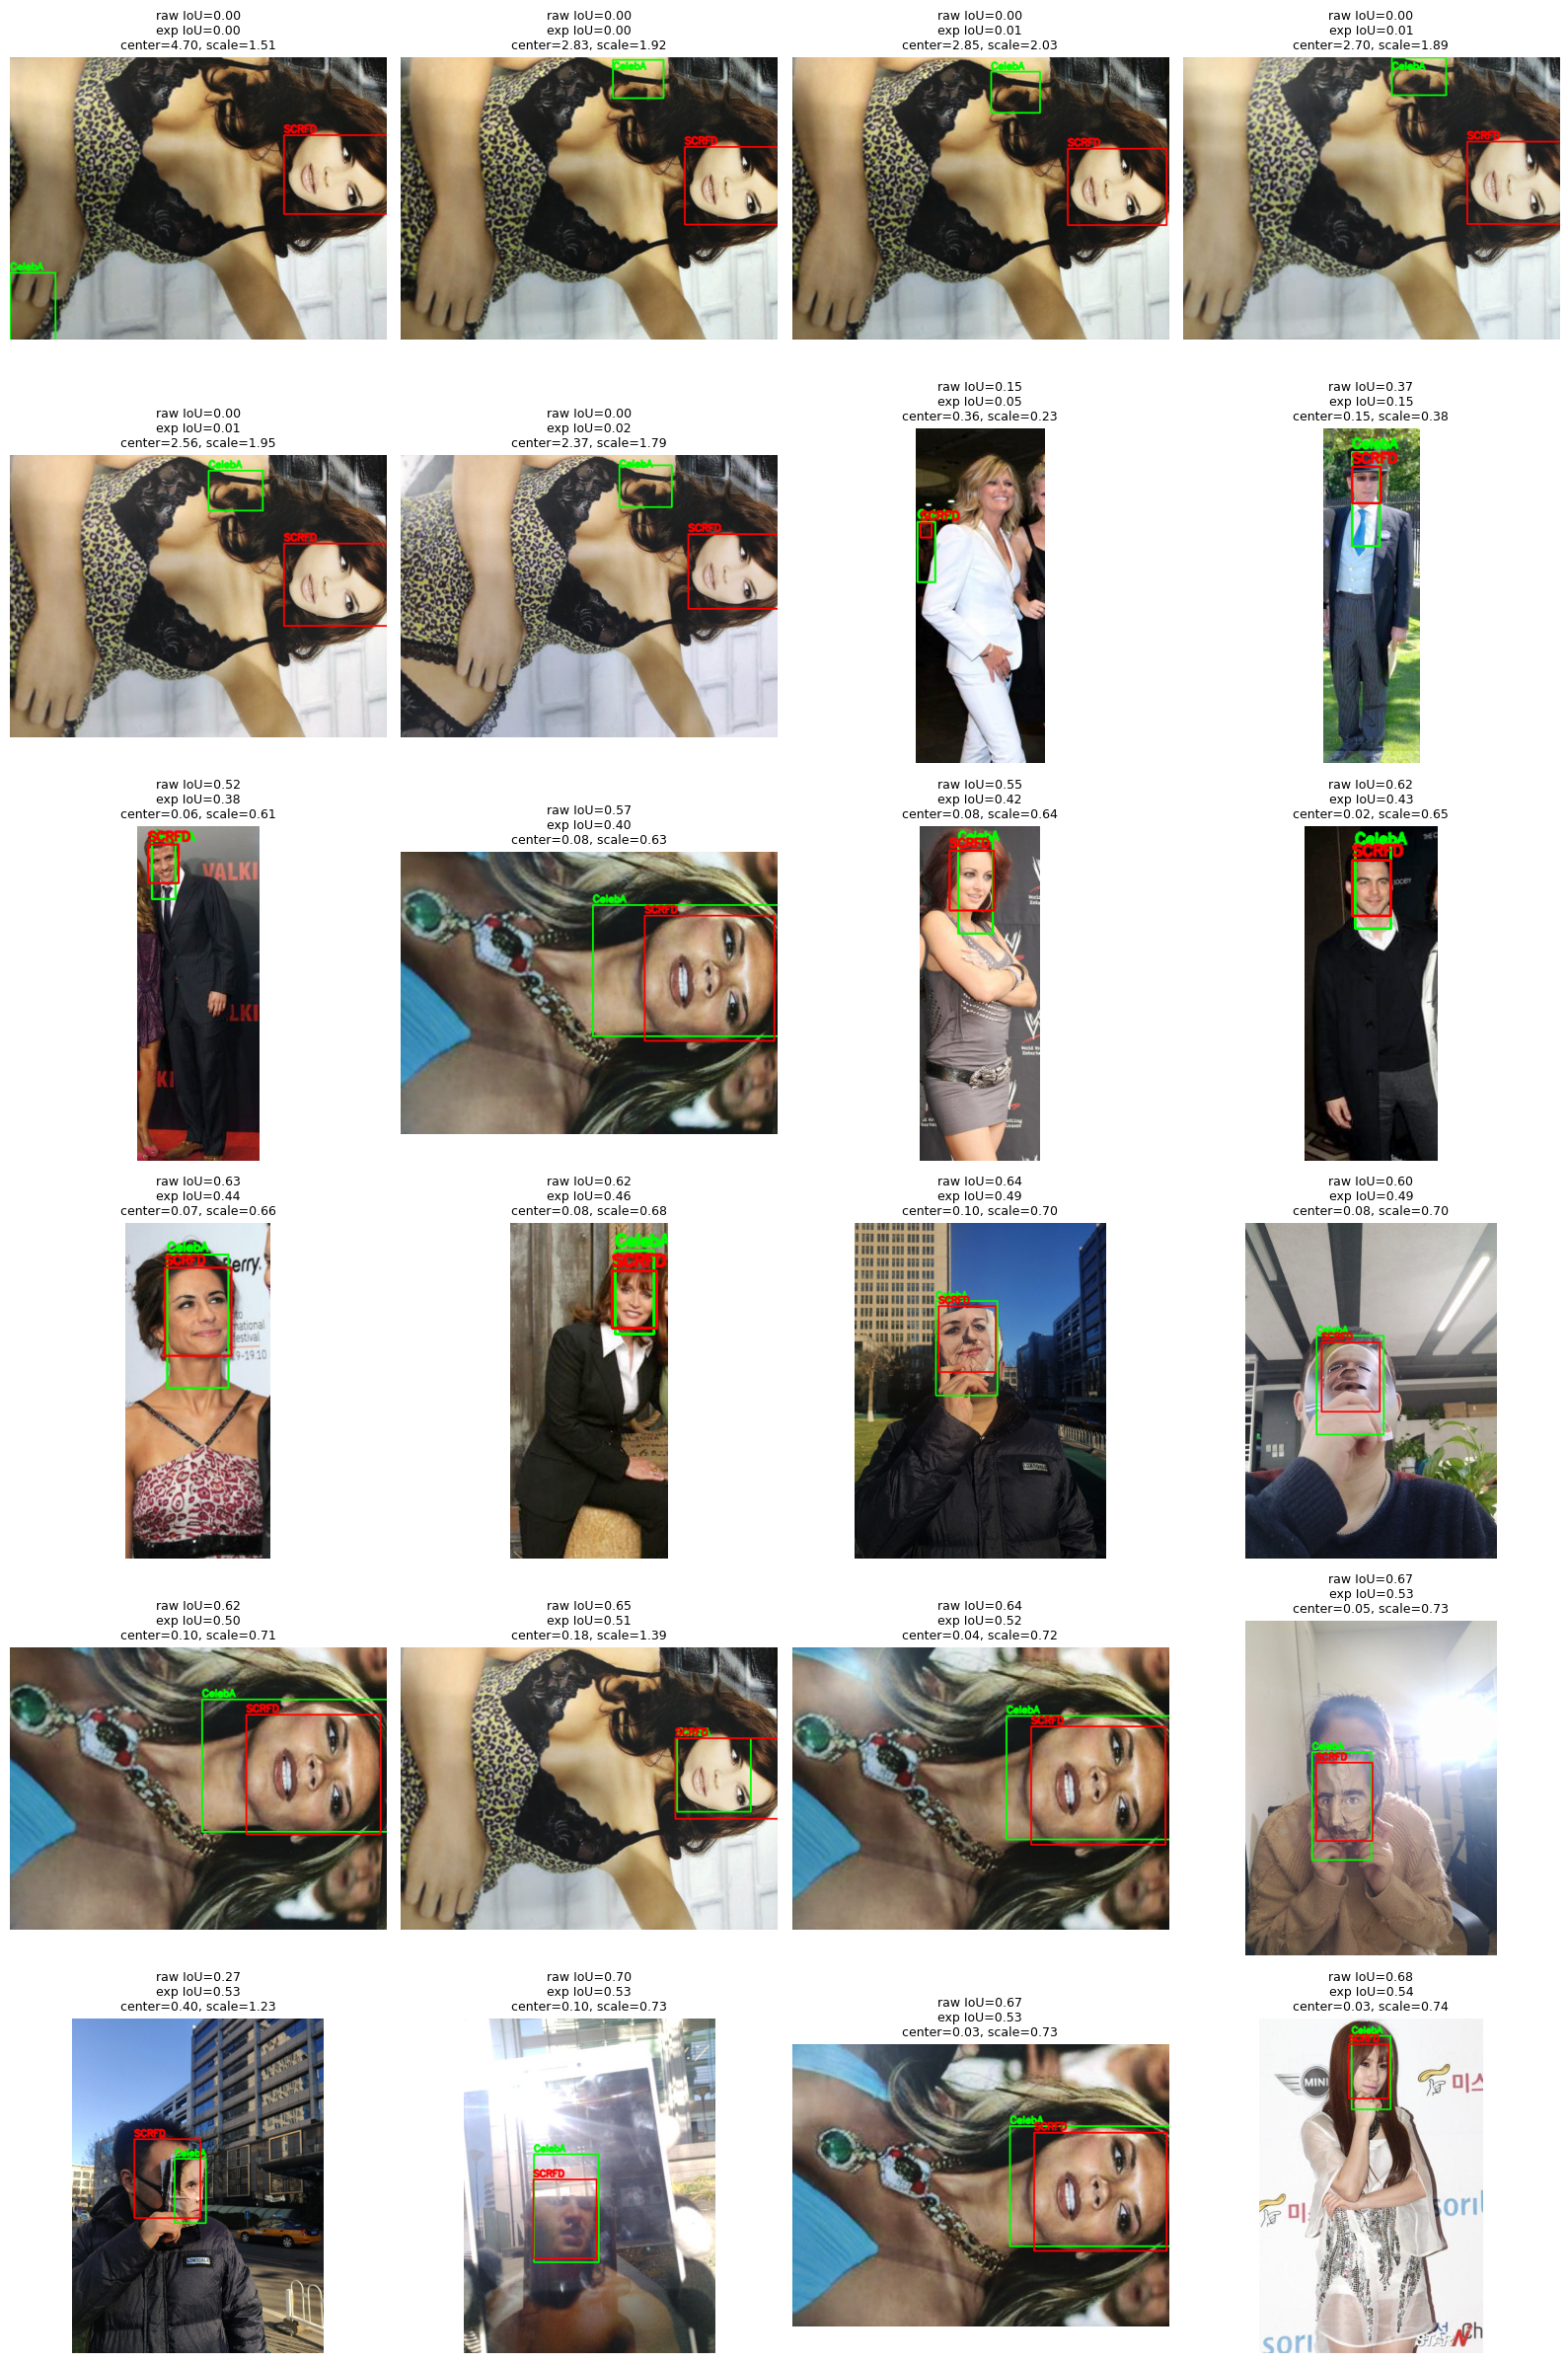

In [10]:

def draw_box(img, b, color, label):
    x1,y1,x2,y2 = [int(round(v)) for v in b]
    cv2.rectangle(img,(x1,y1),(x2,y2),color,2)
    cv2.putText(
        img,label,(max(0,x1),max(20,y1-5)),
        cv2.FONT_HERSHEY_SIMPLEX,0.55,color,2,cv2.LINE_AA
    )

worst = d.sort_values(
    ["expanded_iou","raw_iou","center_shift_norm"],
    ascending=[True,True,False]
).head(SHOW_WORST_N)

cols = 4
rows_n = math.ceil(len(worst)/cols)
fig, axes = plt.subplots(rows_n, cols, figsize=(16,4*rows_n))
axes = np.array(axes).reshape(-1)

for ax in axes:
    ax.axis("off")

for ax, (_,row) in zip(axes,worst.iterrows()):
    img = cv2.imread(str(DATA_ROOT / row["key"]))
    img = cv2.cvtColor(img,cv2.COLOR_BGR2RGB)

    gt = np.array([row.gt_x1,row.gt_y1,row.gt_x2,row.gt_y2],dtype=float)
    det = np.array([row.det_x1,row.det_y1,row.det_x2,row.det_y2],dtype=float)

    vis = img.copy()
    draw_box(vis,gt,(0,255,0),"CelebA")
    draw_box(vis,det,(255,0,0),"SCRFD")

    ax.imshow(vis)
    ax.set_title(
        f"raw IoU={row.raw_iou:.2f}\n"
        f"exp IoU={row.expanded_iou:.2f}\n"
        f"center={row.center_shift_norm:.2f}, scale={row.scale_ratio_det_over_gt:.2f}",
        fontsize=9
    )
    ax.axis("off")

plt.tight_layout()
plt.show()


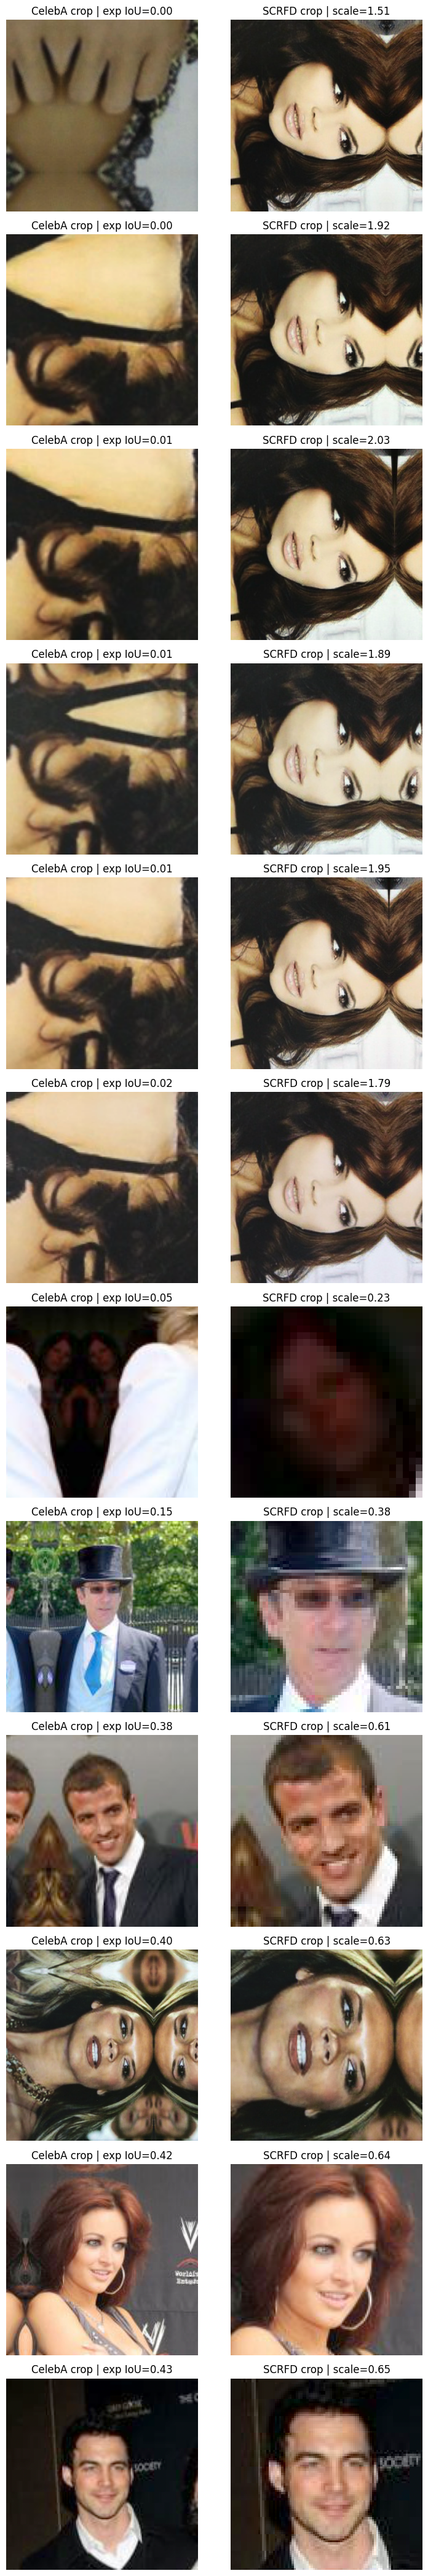

In [11]:

def extract_square_crop_reflect(image_bgr, bbox_xyxy, factor=1.5):
    H,W = image_bgr.shape[:2]
    x1,y1,x2,y2 = map(float,bbox_xyxy)
    w=x2-x1; h=y2-y1

    side=max(w,h)*factor
    cx=x1+w/2.0
    cy=y1+h/2.0

    x_start=int(cx-side/2.0)
    y_start=int(cy-side/2.0)
    crop_size=max(1,int(side))

    crop_x1=max(0,x_start)
    crop_y1=max(0,y_start)
    crop_x2=min(W,x_start+crop_size)
    crop_y2=min(H,y_start+crop_size)

    top=max(0,-y_start)
    left=max(0,-x_start)
    bottom=max(0,(y_start+crop_size)-H)
    right=max(0,(x_start+crop_size)-W)

    cropped=image_bgr[crop_y1:crop_y2,crop_x1:crop_x2]

    out=cv2.copyMakeBorder(
        cropped,int(top),int(bottom),int(left),int(right),
        cv2.BORDER_REFLECT_101,
    )

    if out.shape[:2] != (crop_size,crop_size):
        out=cv2.resize(out,(crop_size,crop_size),interpolation=cv2.INTER_AREA)

    return out

worst_crop = worst.head(min(12,len(worst)))

fig, axes = plt.subplots(len(worst_crop), 2, figsize=(8, 3.5*len(worst_crop)))
if len(worst_crop) == 1:
    axes = np.array([axes])

for r,(_,row) in enumerate(worst_crop.iterrows()):
    image_bgr=cv2.imread(str(DATA_ROOT/row["key"]))

    gt=np.array([row.gt_x1,row.gt_y1,row.gt_x2,row.gt_y2])
    det=np.array([row.det_x1,row.det_y1,row.det_x2,row.det_y2])

    crop_gt=extract_square_crop_reflect(image_bgr,gt,EXPANSION_FACTOR)
    crop_dt=extract_square_crop_reflect(image_bgr,det,EXPANSION_FACTOR)

    crop_gt=cv2.cvtColor(crop_gt,cv2.COLOR_BGR2RGB)
    crop_dt=cv2.cvtColor(crop_dt,cv2.COLOR_BGR2RGB)

    axes[r,0].imshow(crop_gt)
    axes[r,0].set_title(f"CelebA crop | exp IoU={row.expanded_iou:.2f}")
    axes[r,0].axis("off")

    axes[r,1].imshow(crop_dt)
    axes[r,1].set_title(f"SCRFD crop | scale={row.scale_ratio_det_over_gt:.2f}")
    axes[r,1].axis("off")

plt.tight_layout()
plt.show()


In [12]:

median_raw_iou = d["raw_iou"].median()
median_exp_iou = d["expanded_iou"].median()
p10_exp_iou = d["expanded_iou"].quantile(0.10)
median_center = d["center_shift_norm"].median()
median_scale = d["scale_ratio_det_over_gt"].median()
large_frac = (d["shift_category"] == "large").mean()

print("=== BBOX SHIFT SUMMARY ===")
print(f"Detection failure rate        : {failure_rate*100:.2f}%")
print(f"Median raw IoU                : {median_raw_iou:.3f}")
print(f"Median expanded IoU           : {median_exp_iou:.3f}")
print(f"10th percentile expanded IoU  : {p10_exp_iou:.3f}")
print(f"Median normalized center shift: {median_center:.3f}")
print(f"Median detector/GT scale      : {median_scale:.3f}")
print(f"Large-shift fraction          : {large_frac*100:.2f}%")

print("\nInterpretation:")
print("- Expanded IoU is the most relevant number for the PAD pipeline.")
print("- Median expanded IoU ~0.85–0.90+ and low large-shift fraction -> crop shift less likely main cause.")
print("- Frequent expanded IoU <0.70, center shift >0.10, or scale mismatch >20–30% -> substantial crop shift.")
print("- These cutoffs are debugging heuristics, not benchmark standards.")
print("- Strongest causal test after this: run the SAME PAD model on the SAME images using GT crop vs SCRFD crop.")


=== BBOX SHIFT SUMMARY ===
Detection failure rate        : 6.10%
Median raw IoU                : 0.878
Median expanded IoU           : 0.908
10th percentile expanded IoU  : 0.799
Median normalized center shift: 0.025
Median detector/GT scale      : 0.967
Large-shift fraction          : 2.53%

Interpretation:
- Expanded IoU is the most relevant number for the PAD pipeline.
- Median expanded IoU ~0.85–0.90+ and low large-shift fraction -> crop shift less likely main cause.
- Frequent expanded IoU <0.70, center shift >0.10, or scale mismatch >20–30% -> substantial crop shift.
- These cutoffs are debugging heuristics, not benchmark standards.
- Strongest causal test after this: run the SAME PAD model on the SAME images using GT crop vs SCRFD crop.


In [13]:

if SAVE_RESULTS:
    out_csv = Path("/kaggle/working/celeba_scrfd_bbox_shift_results.csv")
    out_summary = Path("/kaggle/working/celeba_scrfd_bbox_shift_summary.json")

    df.to_csv(out_csv,index=False)

    payload = {
        "split": SPLIT,
        "sample_size": len(df),
        "detected": n_detected,
        "detection_failure_rate": float(failure_rate),
        "expansion_factor": EXPANSION_FACTOR,
        "median_raw_iou": float(median_raw_iou),
        "median_expanded_iou": float(median_exp_iou),
        "p10_expanded_iou": float(p10_exp_iou),
        "median_center_shift_norm": float(median_center),
        "median_scale_ratio_det_over_gt": float(median_scale),
        "large_shift_fraction": float(large_frac),
        "heuristic_category_counts": {k:int(v) for k,v in counts.items()},
    }

    with open(out_summary,"w") as f:
        json.dump(payload,f,indent=2)

    print("Saved:")
    print(" ",out_csv)
    print(" ",out_summary)


Saved:
  /kaggle/working/celeba_scrfd_bbox_shift_results.csv
  /kaggle/working/celeba_scrfd_bbox_shift_summary.json
